<a href="https://colab.research.google.com/github/Ashwin-Kotgire-ATX/DocLayout-YOLO/blob/main/cleanlayout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/ppaanngggg/layoutreader.git
!cp -r layoutreader/* .
!rm -r layoutreader

Cloning into 'layoutreader'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 79 (delta 36), reused 61 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 1.55 MiB | 4.21 MiB/s, done.
Resolving deltas: 100% (36/36), done.


In [6]:
from PIL import Image
from surya.layout import LayoutPredictor


In [1]:
# !pip install datasets
!pip install pymupdf -q
!pip install surya-ocr
!pip install doclayout-yolo -q
from huggingface_hub import hf_hub_url,hf_hub_download
import cv2
from PIL import Image
from surya.layout import LayoutPredictor
import json

from doclayout_yolo import YOLOv10
filepath = hf_hub_download(repo_id="juliozhao/DocLayout-YOLO-DocStructBench", filename="doclayout_yolo_docstructbench_imgsz1024.pt")
model = YOLOv10(filepath)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [2]:
import fitz  # PyMuPDF
from PIL import Image
from PIL import Image, ImageDraw
import numpy as np
import torch

"""
In final bounding boxes to be made shuch that the bigger bounding box will not constitute more than 15 percent of the area of the page. If it does then it's children will be used instead.

"""
class pdf_to_images:
  def __init__(self,pdf_path,model,device="cuda:0"):
    self.pdf_path = pdf_path
    self.model = model
    self.pages_as_images=self.pdf_page_to_image()
    self.model_class_map={0: 'title', 1: 'plain text', 2: 'abandon', 3: 'figure',
                          4: 'figure_caption', 5: 'table', 6: 'table_caption',
                          7: 'table_footnote', 8: 'isolate_formula', 9: 'formula_caption'}
    self.annotated_frame=[]
    self.device=device
  def pdf_page_to_image(self):
    pdf_document = fitz.open(self.pdf_path)
    images=[]
    for page in pdf_document:

      pix = page.get_pixmap(matrix=fitz.Matrix(3,3))  # 3x3 matrix scales the resolution
      # pix.save(output_image_path)

      # print(f"Page saved as HD image: {output_image_path}")

      image = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
      images.append(image)
    pdf_document.close()
    return images
  def intersection_by_current(self,b1,b2):
    x1=b1[0] if(b1[0]>b2[0])  else b2[0]
    y1=b1[1] if(b1[1]>b2[1])  else b2[1]
    x2=b1[2] if(b1[2]<b2[2])  else b2[2]
    y2=b1[3] if(b1[3]<b2[3])  else b2[3]
    if(x2<x1 or y2<y1):
      return [-1,-1,-1,-1]
    return [x1,y1,x2,y2]
  def find_super_parents(self,arr):
    temp_array=arr[:]

  def improve_bounding_box(self,bounding_boxes,classes):
    areas=[(k-i)*(l-j) for i,j,k,l in bounding_boxes]
    final_bounding_boxes=list(range(len(bounding_boxes)))

    for i in range(len(bounding_boxes)):
      for j in range(i+1,len(bounding_boxes)):

        inter=self.intersection_by_current(bounding_boxes[i],bounding_boxes[j])
        # print(inter)
        if(inter[0]==-1):
          continue
        else:
          area_inter=(inter[2]-inter[0])*(inter[3]-inter[1])
          ar_1=  (bounding_boxes[i][2]-bounding_boxes[i][0])*(bounding_boxes[i][3]-bounding_boxes[i][1])
          ar_2=  (bounding_boxes[j][2]-bounding_boxes[j][0])*(bounding_boxes[j][3]-bounding_boxes[j][1])
          smaller_ar_box=i if(ar_1<ar_2) else j
          larger_ar_box=i if(ar_1>ar_2) else j
          smaller_area=areas[smaller_ar_box]
          area_ratio=(inter[2]-inter[0])*(inter[3]-inter[1]) /smaller_area
          # print(area_inter,area_ratio)
          if(area_ratio>0.90):
            final_bounding_boxes[i]=larger_ar_box
            final_bounding_boxes[j]=larger_ar_box
            classes[i]=classes[larger_ar_box]
            classes[j]=classes[larger_ar_box]
    bounding_boxes=np.array([bounding_boxes[i] for i in final_bounding_boxes])
    classes=np.array([classes[i] for i in final_bounding_boxes],'int')
    final_bounding_boxes_=final_bounding_boxes[:]

    final_bounding_boxes=list(set(final_bounding_boxes))

    bounding_boxes=np.array([bounding_boxes[i] for i in final_bounding_boxes])
    classes=np.array([classes[i] for i in final_bounding_boxes],'int')
    return bounding_boxes,classes

  def get_bounding_boxes_of_tables_and_figures(self,page):
      """
      Heuristic function to identify bounding boxes of tables and figures.
      Currently uses 'blocks' method.
      """
      with torch.no_grad():
        det_res = self.model.predict(page,imgsz=1024,conf=0.15,device=self.device)

      model_class_map={0: 'title', 1: 'plain text', 2: 'abandon', 3: 'figure',
                            4: 'figure_caption', 5: 'table', 6: 'table_caption',
                            7: 'table_footnote', 8: 'isolate_formula', 9: 'formula_caption'}

      classes=det_res[0].boxes.cls.cpu().numpy()

      ci=[]

      bounding_boxes =det_res[0].boxes.xyxyn.cpu().numpy()
      bounding_boxes,classes=self.improve_bounding_box(bounding_boxes,classes)
      annotated_frame = det_res[0].plot(pil=True, line_width=5, font_size=20)

      annf=Image.fromarray(annotated_frame)
      return bounding_boxes,classes,annf

  def resize_bounding_box(self,bounding_boxes,new_width,new_height,o_height=1,o_width=1):
    temp=[]
    for i in bounding_boxes:
      temp.append([i[0]*new_width/o_width,i[1]*new_height/o_height,i[2]*new_width/o_width,i[3]*new_height/o_height])

    return temp
  def get_all_bounding_boxes_and_classes(self):
    bounding_boxes=[]
    classes=[]
    i=0
    self.annotated_frame=[]
    cropped_images=[]
    for image in self.pages_as_images:
      print('-'*100,'\n',i)
      i+=1
      bb,cl,af=self.get_bounding_boxes_of_tables_and_figures(image)
      self.annotated_frame.append(af)
      bounding_boxes.append(bb)
      classes.append(cl)
    return bounding_boxes,classes
  def get_bounded_image(self,image,bounding_boxes):
    bbs=[]
    for bb in bounding_boxes:
        bbs.append(image.crop(bb))
    return bbs

  def ordered_bounding_boxes(self,page_number):
    image = a.pages_as_images[page_number]
    layout_predictor = LayoutPredictor()

    # layout_predictions is a list of dicts, one per image
    layout_predictions = layout_predictor([image])
    bboxes=[i['bbox'] for i in json.loads(layout_predictions[0].model_dump_json())['bboxes']]
    return bboxes
  def order_box_indices(self,list1, list2, overlap_thresh=0.5):
    """
    Determines the reading order indices for big boxes in list1 based on the
    reading order of smaller boxes in list2.

    Instead of returning the boxes themselves, this function returns the indices
    of list1 in the inferred reading order.

    Parameters:
      list1: list of bigger bounding boxes, each as (x1, y1, x2, y2)
      list2: list of smaller bounding boxes (arranged in reading order)
      overlap_thresh: threshold for considering a list2 box as being "inside"
                      a list1 box (ratio of intersection area to list2 box area).
                      Default is 0.5.

    Returns:
      A list of indices corresponding to the boxes in list1, sorted in reading order.
    """

    def area(box):
        x1, y1, x2, y2 = box
        return max(0, x2 - x1) * max(0, y2 - y1)

    def intersection(boxA, boxB):
        x1 = max(boxA[0], boxB[0])
        y1 = max(boxA[1], boxB[1])
        x2 = min(boxA[2], boxB[2])
        y2 = min(boxA[3], boxB[3])
        return max(0, x2 - x1) * max(0, y2 - y1)

    def overlap_ratio(box_small, box_large):
        """
        Computes the ratio of the area of box_small that overlaps with box_large.
        (Typically, box_small is a list2 box and box_large is a list1 box.)
        """
        inter = intersection(box_small, box_large)
        return inter / area(box_small) if area(box_small) > 0 else 0

    # Compute a reading order value for each box in list1 based on list2 overlap.
    order_values = []
    for box1 in list1:
        candidate_indices = []
        for i, box2 in enumerate(list2):
            # If a significant portion of box2 overlaps with box1, consider it a match.
            if overlap_ratio(box2, box1) >= overlap_thresh:
                candidate_indices.append(i)
        if candidate_indices:
            # Use the earliest (lowest index) reading order index among overlapping boxes.
            order_values.append(min(candidate_indices))
        else:
            # If no box from list2 sufficiently overlaps, assign a high order value.
            order_values.append(float('inf'))

    # Create a sorted list of indices from list1 based on the order_values.
    sorted_indices = [i for i, _ in sorted(enumerate(order_values), key=lambda pair: pair[1])]
    return sorted_indices

  def mask_bounding_boxes_and_extract_text(self,output_pdf_path=None):
      """
      Mask bounding boxes (tables/figures) on each PDF page and extract text.
      """
      # Open the PDF
      pdf_document = fitz.open(self.pdf_path)
      tables_figures=[]
      classes__=[]
      bounding_boxes_o=[]
      classes_o=[]

      for page in pdf_document:

          page_width = page.rect.width   # Width in points
          page_height = page.rect.height
          pix = page.get_pixmap(matrix=fitz.Matrix(3,3))
          # pix.save(output_image_path)

          # print(f"Page saved as HD image: {output_image_path}")
          # pdf_document.close()
          image = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
          bounding_boxes,classes = self.get_bounding_boxes_of_tables_and_figures(image)
          # classes.append(classes)
          bb_o=[]
          cl_o=[]
          for i in range(len(bounding_boxes)):
            if(classes[i] in [0,1,3,4,5,6,7,8,9]):
              bb_o.append(bounding_boxes[i])
              cl_o.append(classes[i])
          bounding_boxes_o.append(self.resize_bounding_box(bb_o,image.size[0],image.size[1]))
          classes_o.append(cl_o)
          images_boxes=[]
          clas_fig_tables=[]
          for i in range(len(bounding_boxes)):
            if(classes[i] in [3,5]):
              images_boxes.append(bounding_boxes[i])
              clas_fig_tables.append(classes[i])

          bb_image=self.resize_bounding_box(images_boxes,image.size[0],image.size[1])

          data_as_images=[]
          for box in bb_image:
            left = int(box[0])
            top = int(box[1])
            right = int(box[2])
            bottom = int(box[3])
            cropped_image = image.crop((left, top, right, bottom))
            data_as_images.append(cropped_image)

          pdf_boxes=[]
          for i in range(len(bounding_boxes)):
            if(classes[i] in [3,5,2]):
              pdf_boxes.append(bounding_boxes[i])
          bb_pdf=self.resize_bounding_box(pdf_boxes,page_width,page_height)
          for box in bb_pdf:
              rect = fitz.Rect(box[0], box[1], box[2], box[3])
              page.draw_rect(rect, color=(1, 1, 1), fill=True)
              page.draw_rect(rect, color=(1, 0, 0),fill=True)
              page.add_redact_annot(rect)
              page.apply_redactions()
          page.wrap_contents()

          tables_figures.append(data_as_images)
          classes__.append(clas_fig_tables)
      # Save the modified PDF
      if(output_pdf_path!=None):
        pdf_document.save(output_pdf_path)

      # masked_pdf = fitz.open(output_pdf_path)
      extracted_text =[]
      for page in pdf_document:
          extracted_text .append(page.get_text())

      pdf_document.close()

      return extracted_text,tables_figures,classes__,bounding_boxes_o,classes_o


In [3]:
a=pdf_to_images("/content/NipponIndia-Factsheet-January-2025.pdf",model)

In [4]:
temp=a.get_all_bounding_boxes_and_classes()

---------------------------------------------------------------------------------------------------- 
 0

0: 1024x832 3 titles, 5 plain texts, 4 abandons, 3 figures, 1 figure_caption, 1 table, 1 table_footnote, 137.2ms
Speed: 25.8ms preprocess, 137.2ms inference, 381.9ms postprocess per image at shape (1, 3, 1024, 832)
---------------------------------------------------------------------------------------------------- 
 1

0: 1024x800 1 abandon, 3 tables, 1 table_caption, 87.7ms
Speed: 6.9ms preprocess, 87.7ms inference, 2.5ms postprocess per image at shape (1, 3, 1024, 800)
---------------------------------------------------------------------------------------------------- 
 2

0: 1024x800 8 titles, 23 plain texts, 3 abandons, 83.4ms
Speed: 6.9ms preprocess, 83.4ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 800)
---------------------------------------------------------------------------------------------------- 
 3

0: 1024x800 8 titles, 22 plain texts, 2 abandons, 1

In [18]:
page=9

In [12]:
actual_bbxs=a.resize_bounding_box(temp[0][page],a.pages_as_images[page].width,a.pages_as_images[page].height)
# actual_bbxs

In [24]:
ordered_bbxs=a.ordered_bounding_boxes(page)
ordered_big_boxes=list(np.array(actual_bbxs)[a.order_box_indices(actual_bbxs,ordered_bbxs)])

Loaded layout model datalab-to/surya_layout on device cuda with dtype torch.float16


Recognizing layout: 100%|██████████| 1/1 [00:01<00:00,  1.19s/it]


In [16]:
def draw_bounding_boxes(image, boxes, color="blue", width=2,resize=True):
    """
    Draws bounding boxes on a PIL image.

    :param image: PIL Image object
    :param boxes: List of bounding boxes [(x1, y1, x2, y2), ...]
    :param color: Color of the bounding box
    :param width: Line width of the bounding box
    :return: PIL Image with drawn bounding boxes
    """
    image=image.copy()
    draw = ImageDraw.Draw(image)
    if(resize):
      boxes=a.resize_bounding_box(boxes,image.size[0],image.size[1])
    for box in boxes:
        draw.rectangle(box, outline=color, width=width)
    return image



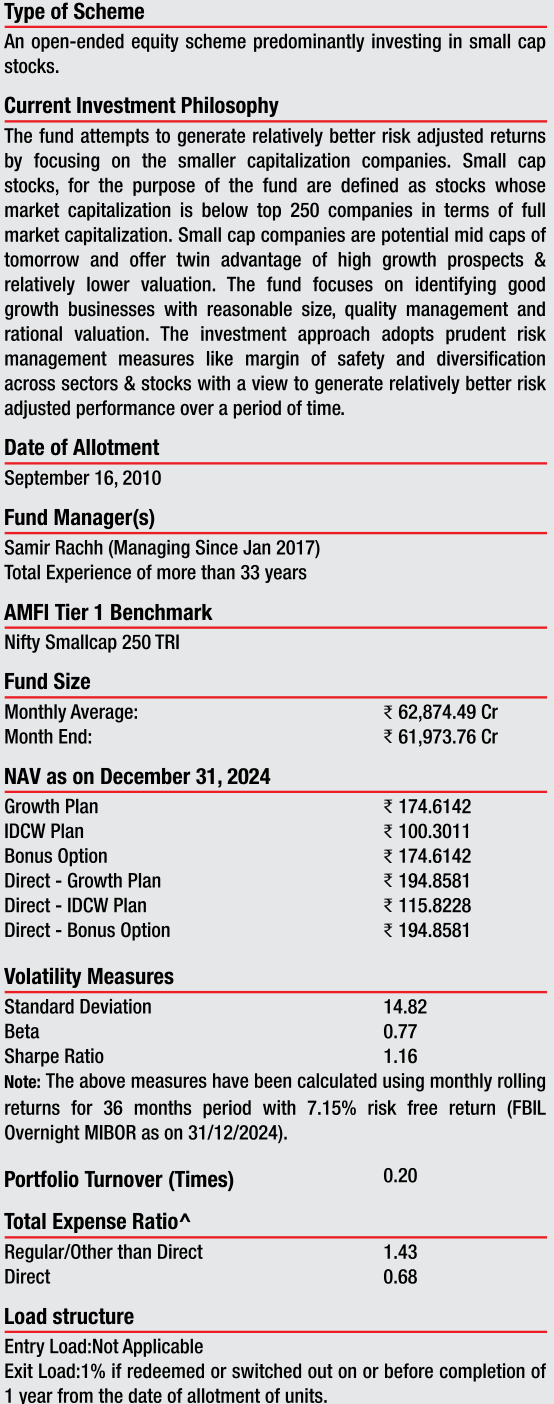

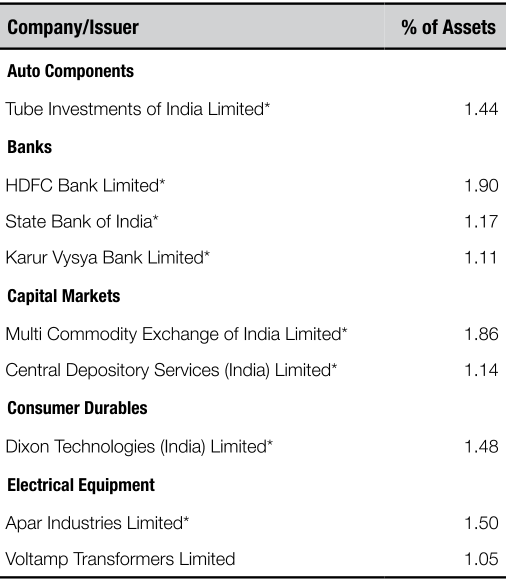

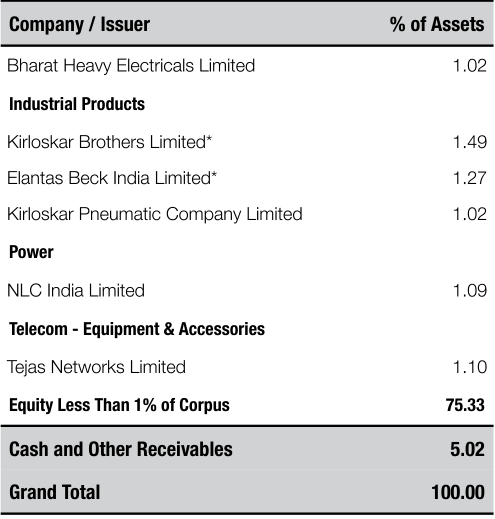

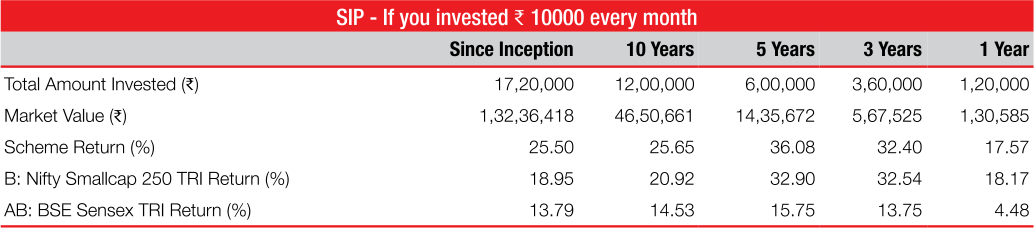

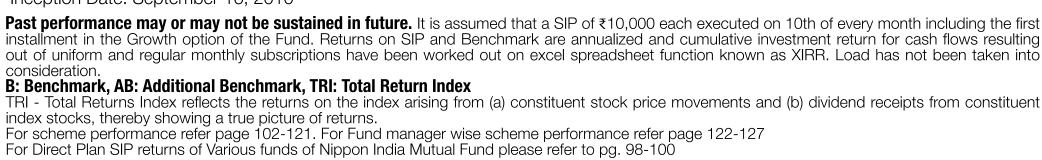

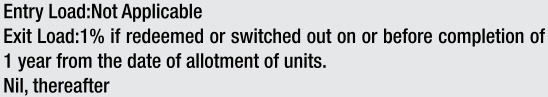

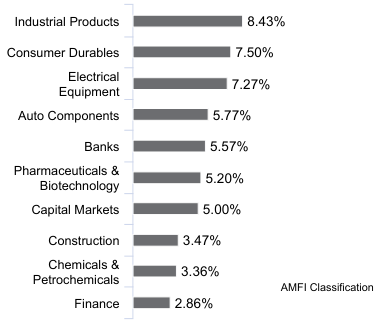

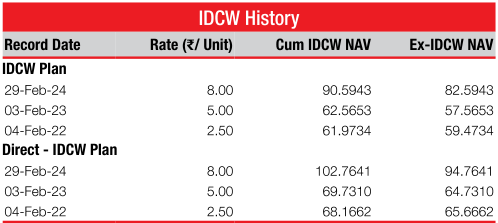

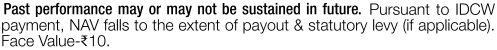

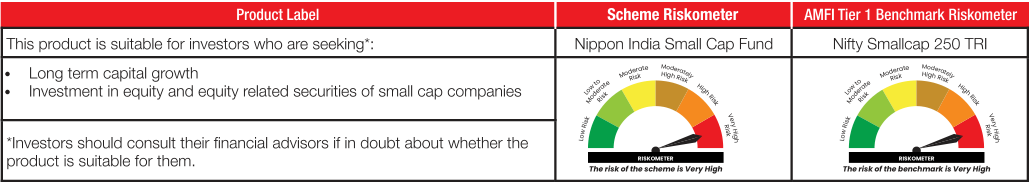

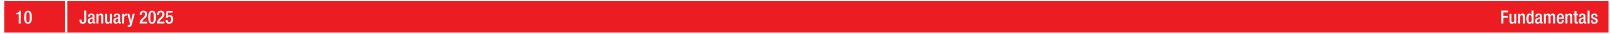

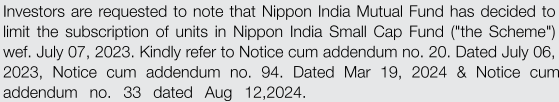

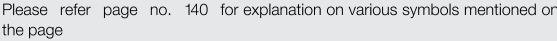

In [25]:
from IPython.display import display
from PIL import Image
croped=a.get_bounded_image(a.pages_as_images[page],ordered_big_boxes)

# Assuming `croped` is a list of cropped images
for img in croped:  # Ensure 'cropped' contains the images
    display(img)

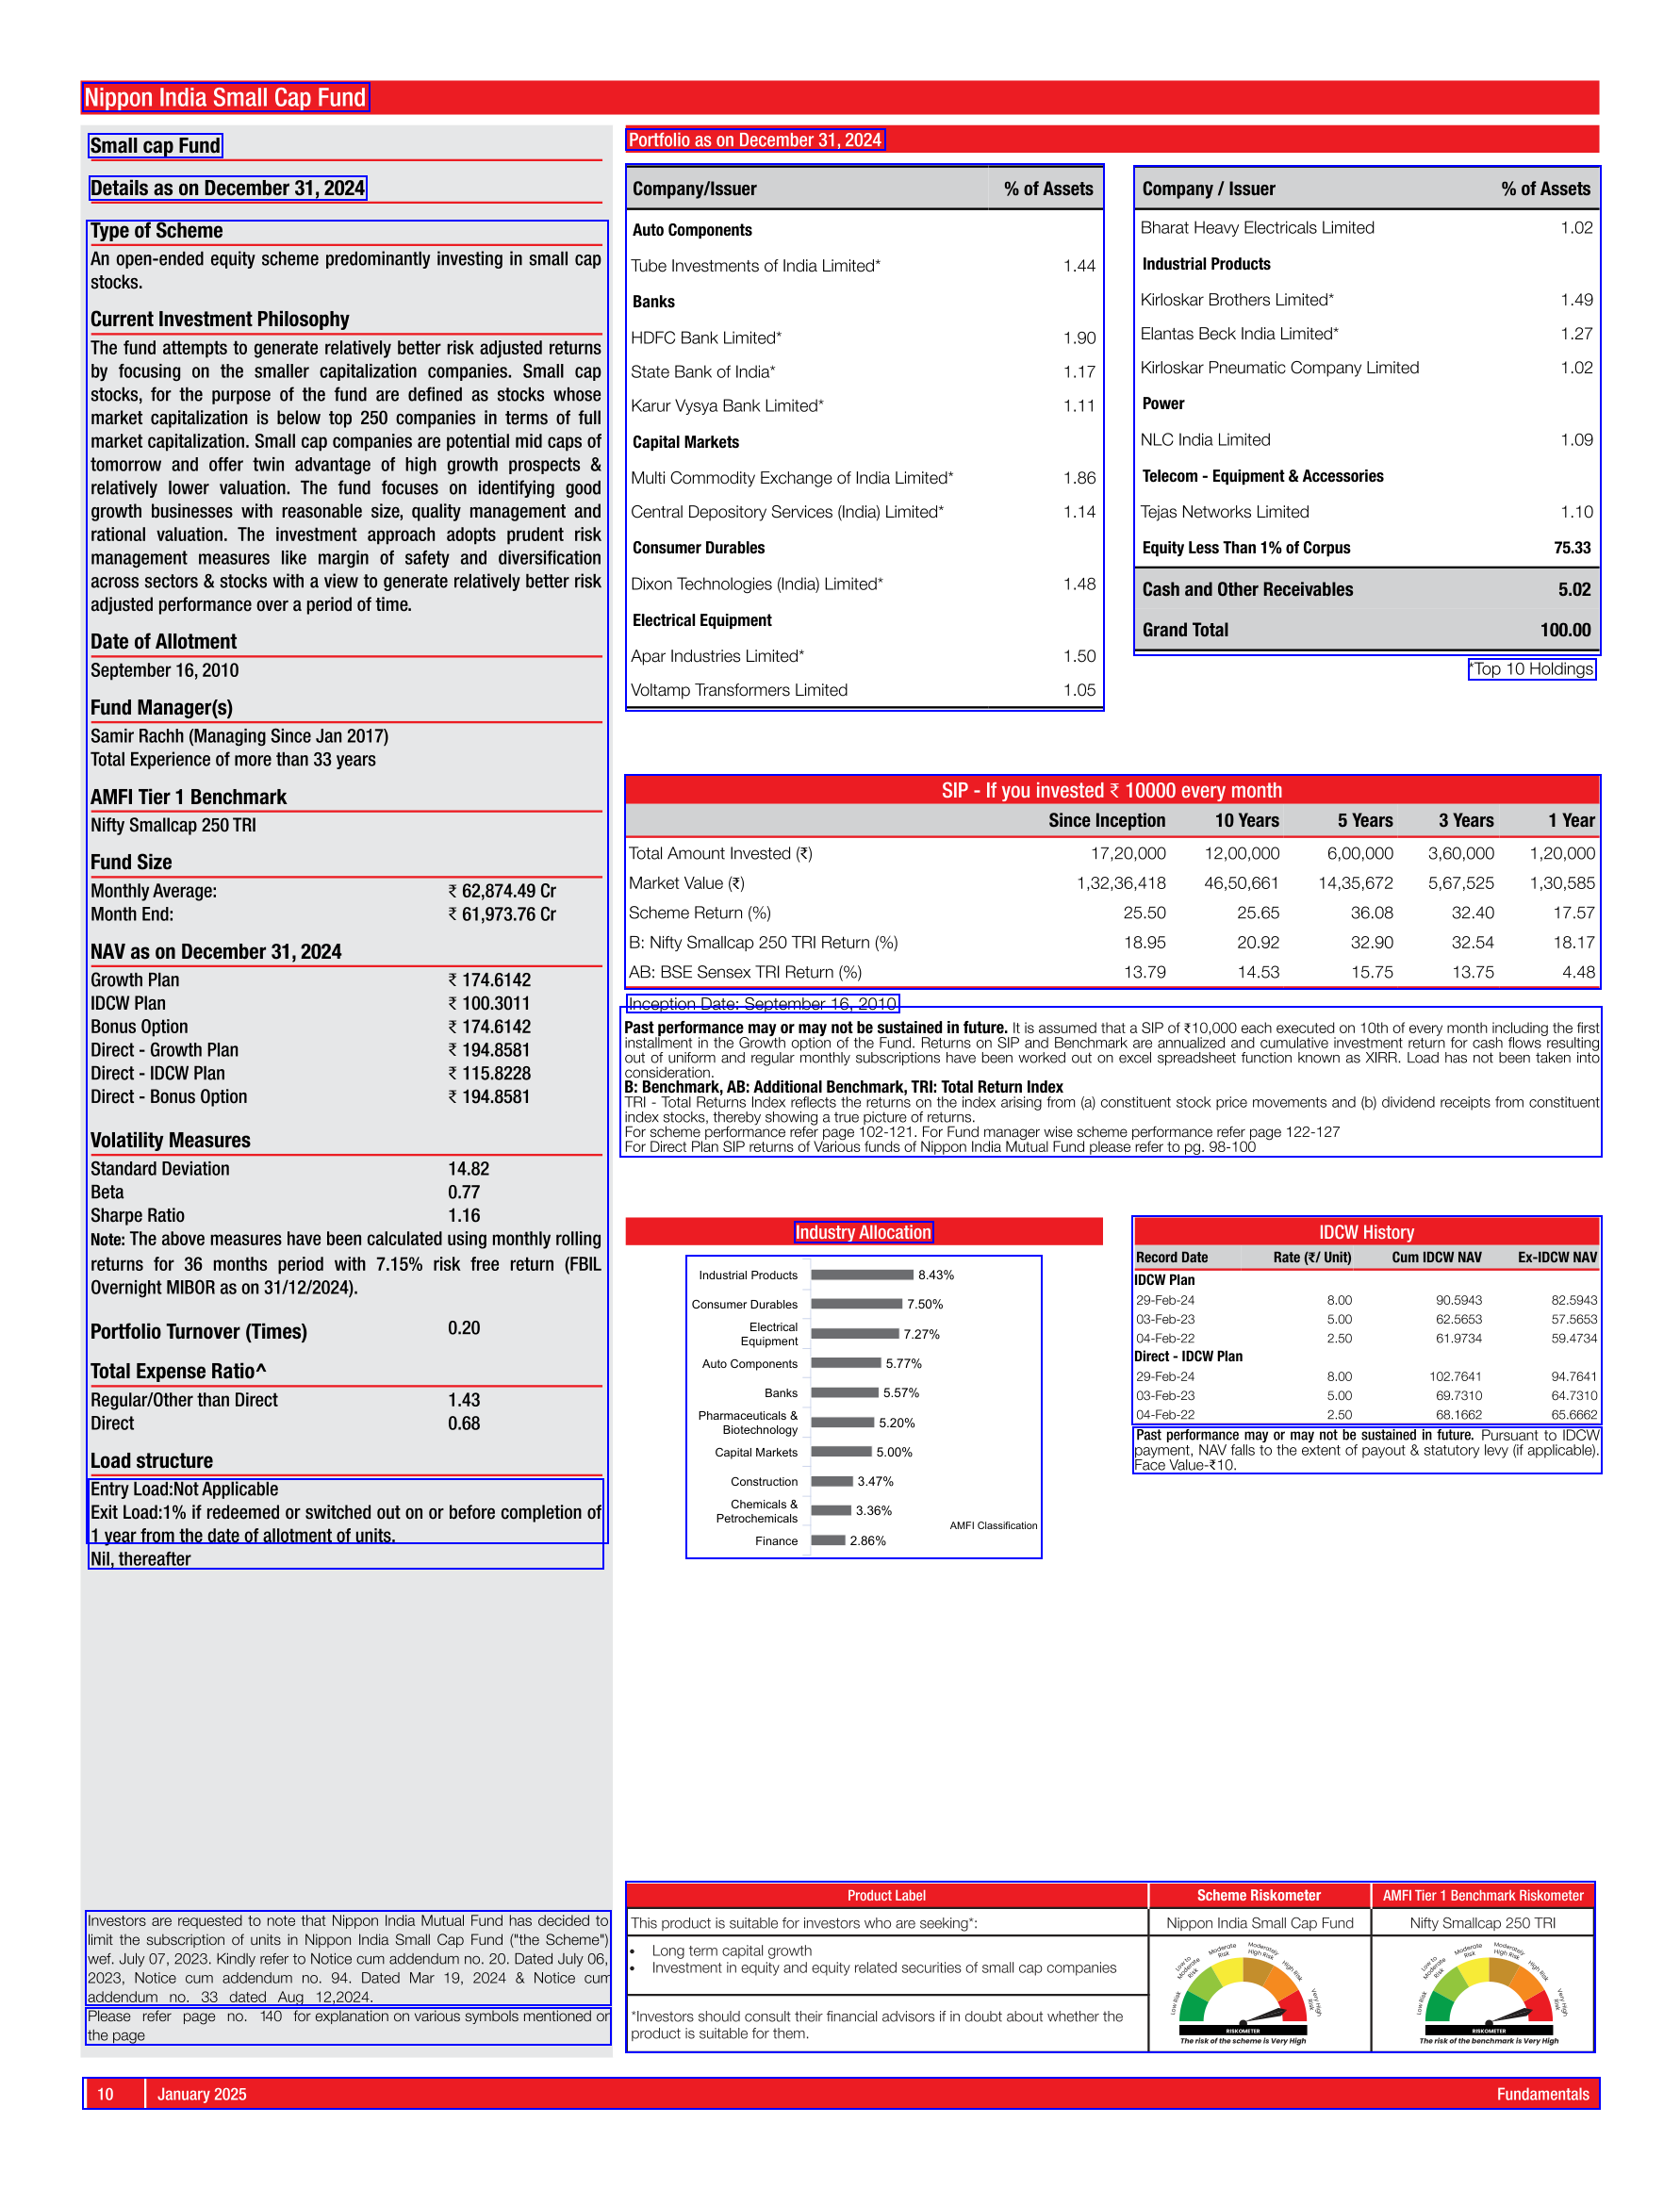

In [17]:
temp_image=draw_bounding_boxes(a.pages_as_images[9],actual_bbxs,resize=False)
temp_image

In [6]:
from transformers import LayoutLMv3ForTokenClassification
from v3.helpers import prepare_inputs, boxes2inputs, parse_logits

model_order = LayoutLMv3ForTokenClassification.from_pretrained("hantian/layoutreader")


ModuleNotFoundError: No module named 'v3'

In [14]:

# list of [left, top, right, bottom], bboxes of spans, should be range from 0 to 1000
boxes =   np.array(a.resize_bounding_box(temp[0][9],1000,1000),'int')
print(boxes)
inputs = boxes2inputs(list(boxes))
inputs = prepare_inputs(inputs, model)
logits = model_order(**inputs).logits.cpu().squeeze(0)
orders = parse_logits(logits, len(boxes))
print(orders)

# [0, 1, 2, ...]

[[673 555 953 650]
 [372  74 657 324]
 [371 353 953 451]
 [674  75 953 299]
 [ 50 872 364 916]
 [ 51 916 363 934]
 [ 52 675 359 717]
 [408 573 620 711]
 [372 859 949 937]
 [ 52  60 132  71]
 [ 49 948 952 963]
 [472 557 556 568]
 [874 300 950 310]
 [ 48  37 220  51]
 [372  58 526  68]
 [372 454 535 462]
 [ 53  80 218  91]
 [674 651 953 673]
 [368 459 953 528]
 [ 51 100 362 705]]


NameError: name 'boxes2inputs' is not defined

In [ ]:
i=-1

In [ ]:
i+=1
image=a.pages_as_images[9]
bb=temp[0][9]
croped=a.get_bounded_image(image,a.resize_bounding_box(bb,image.width,image.height))
croped[orders[i]]

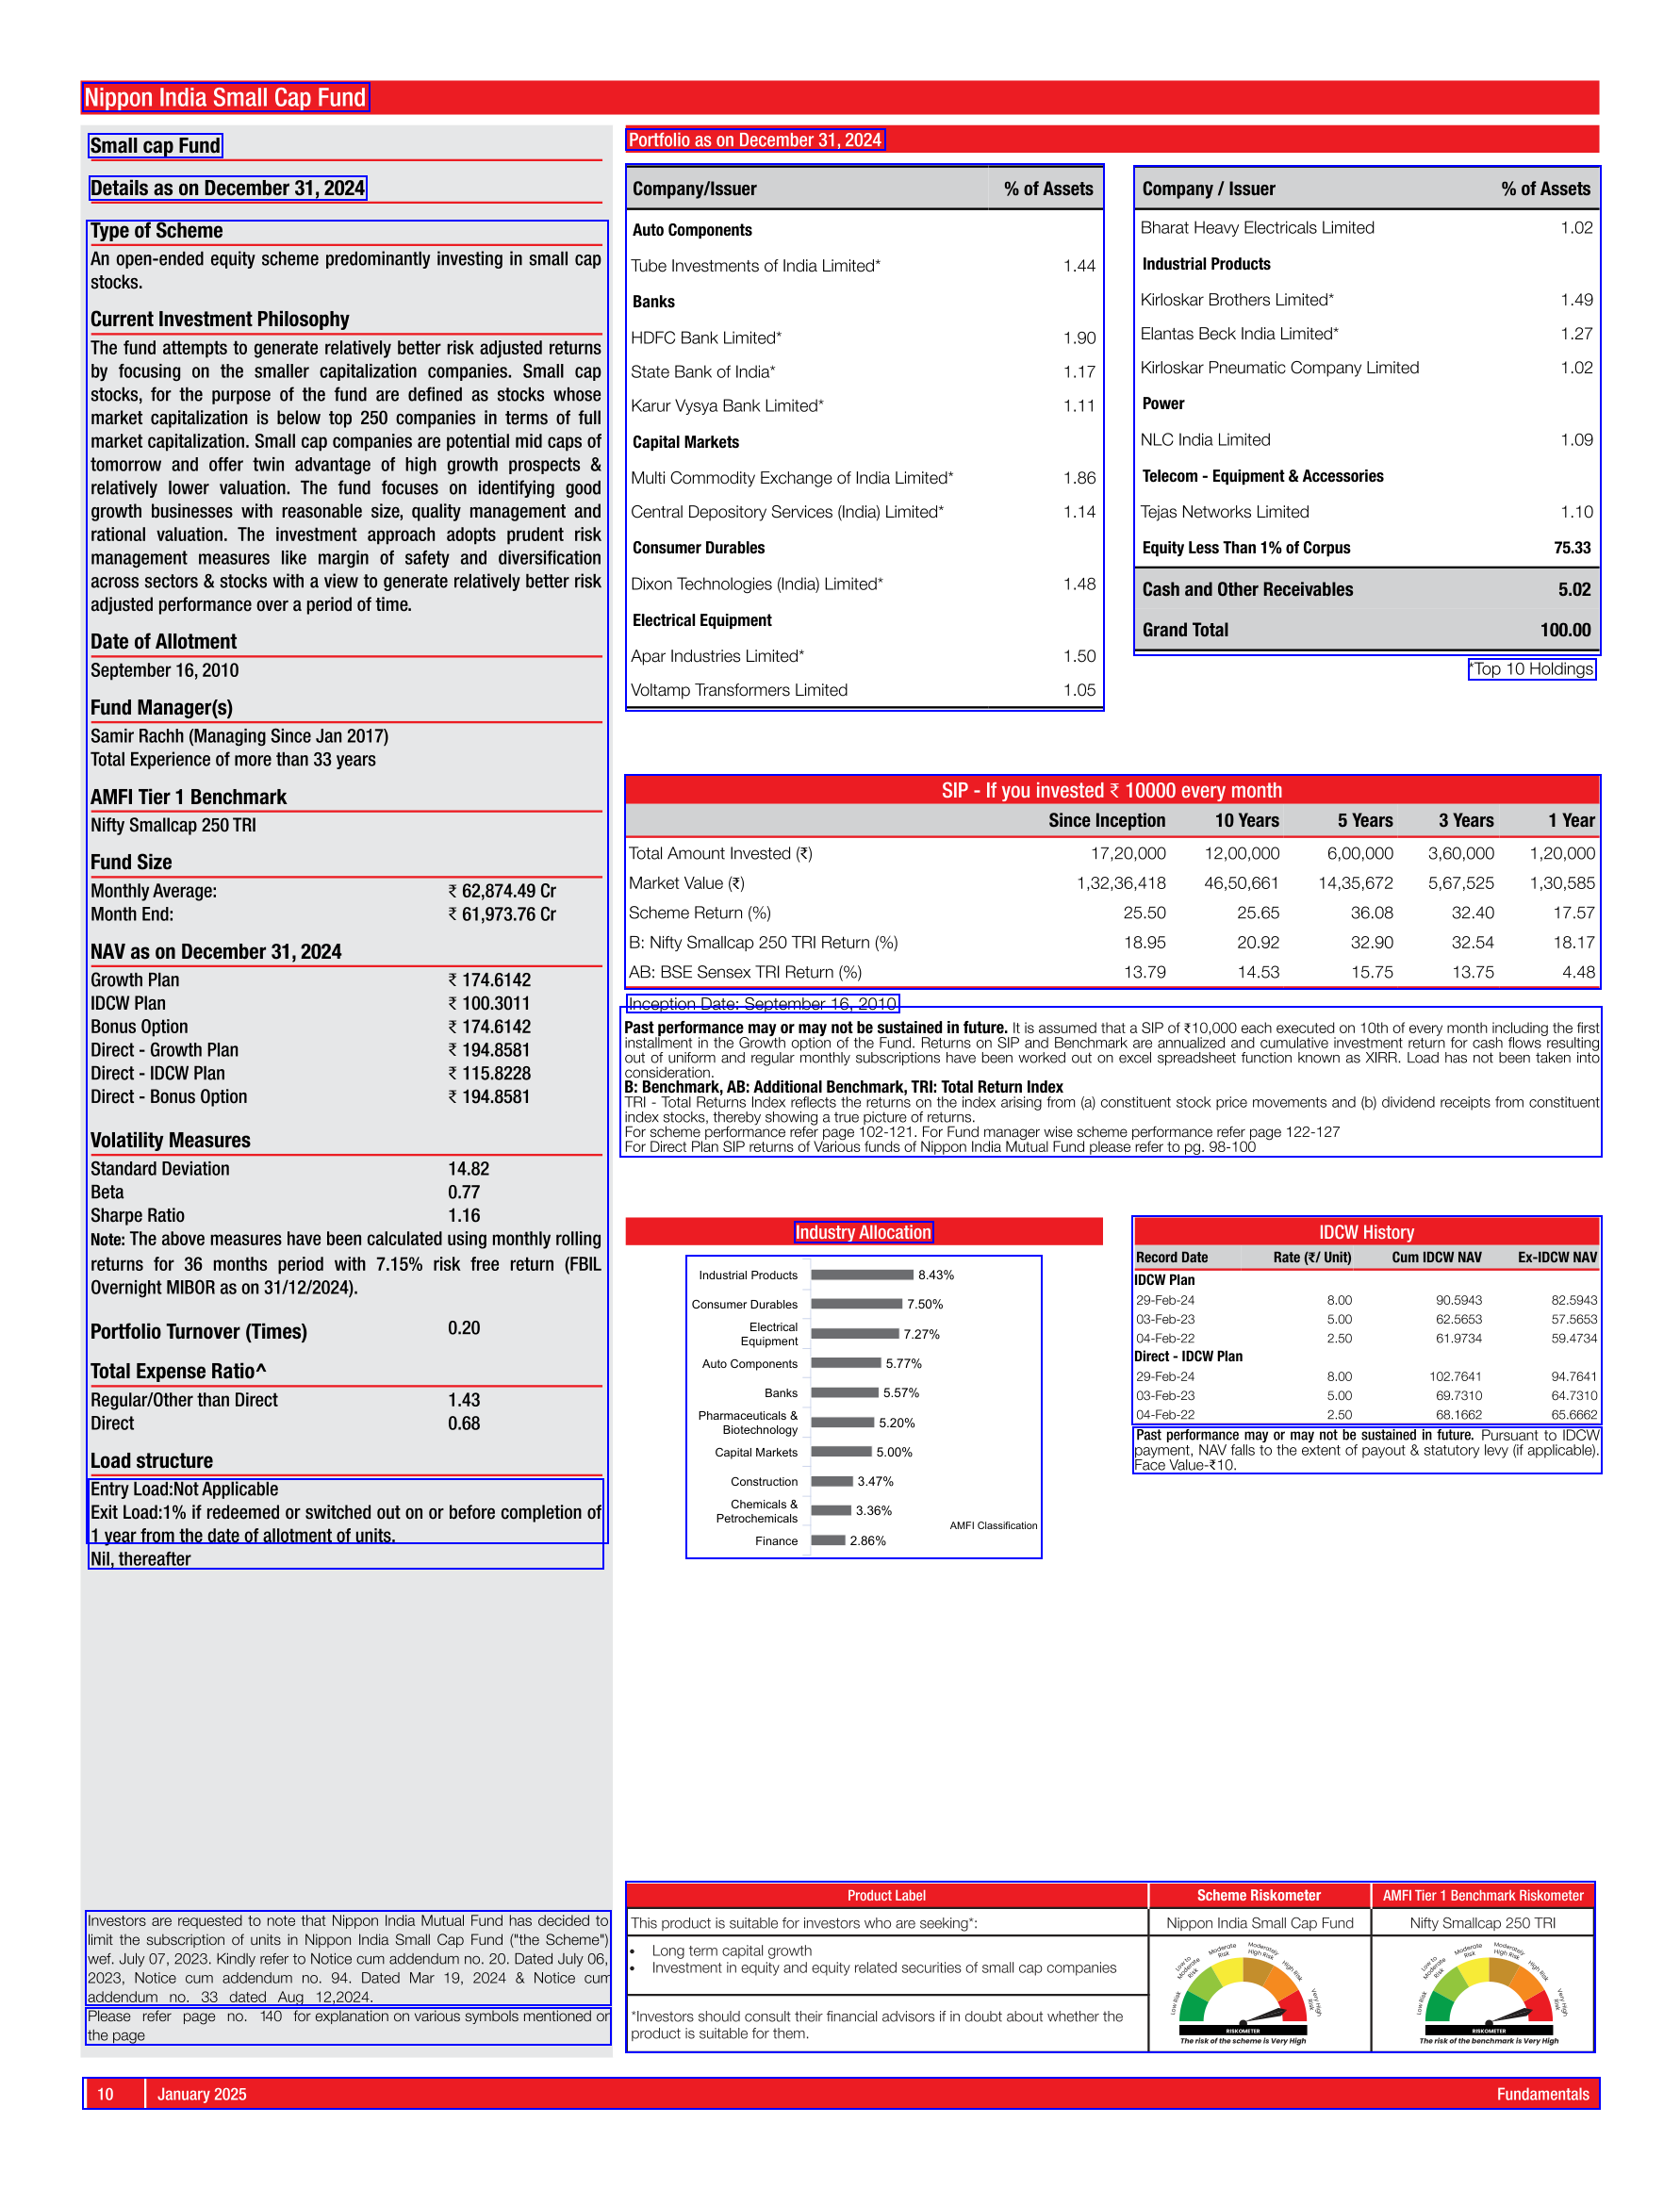

In [24]:
page=9
draw_bounding_boxes(a.pages_as_images[page],temp[0][page])

In [ ]:
!pip install surya-ocr

In [16]:
from PIL import Image
from surya.layout import LayoutPredictor

image = a.pages_as_images[9]
layout_predictor = LayoutPredictor()

# layout_predictions is a list of dicts, one per image
layout_predictions = layout_predictor([image])
bboxes=[i['bbox'] for i in json.loads(layout_predictions[0].model_dump_json())['bboxes']]


Loaded layout model datalab-to/surya_layout on device cuda with dtype torch.float16


Recognizing layout: 100%|██████████| 1/1 [00:02<00:00,  2.17s/it]


In [17]:
import json

In [ ]:
json.loads(layout_predictions[0].model_dump_json())

In [73]:
bboxes

[[88.31689453125, 88.623046875, 385.89697265625, 118.9453125],
 [93.755126953125, 143.6279296875, 233.19140625, 167.578125],
 [92.9937744140625, 188.818359375, 396.33837890625, 211.669921875],
 [92.93939208984375, 233.056640625, 239.2822265625, 256.201171875],
 [93.320068359375, 264.2578125, 637.7958984375, 309.66796875],
 [93.4288330078125, 325.48828125, 371.97509765625, 349.51171875],
 [96.365478515625, 358.0078125, 642.146484375, 653.3203125],
 [94.2989501953125, 668.5546875, 254.07421875, 691.9921875],
 [93.59197998046875, 700.78125, 253.63916015625, 721.875],
 [93.6463623046875, 740.0390625, 246.2431640625, 763.4765625],
 [94.625244140625, 769.3359375, 423.529541015625, 817.3828125],
 [94.0814208984375, 833.7890625, 305.84619140625, 856.0546875],
 [95.495361328125, 865.4296875, 274.304443359375, 886.5234375],
 [96.365478515625, 904.6875, 475.9541015625, 1083.984375],
 [106.154296875, 757.6171875, 453.3310546875, 825.5859375],
 [158.2525634765625, 956.25, 568.62158203125, 1113.2812

In [35]:
bboxes=[i['bbox'] for i in json.loads(layout_predictions[0].model_dump_json())['bboxes']]
bboxes_resized=a.resize_bounding_box(bboxes,1.0,1.0,o_height=image.height,o_width=image.width)
lay=a.resize_bounding_box(temp[0][page],a.pages_as_images[page].width,a.pages_as_images[page].height)

In [108]:
def order_boxes(list1, list2, overlap_thresh=0.5):
    """
    Orders boxes in list1 based on the reading order of boxes in list2,
    using an overlap-based method rather than just a center-point check.

    Parameters:
      list1: list of bigger bounding boxes, each as (x1, y1, x2, y2)
      list2: list of smaller bounding boxes (arranged in reading order)
      overlap_thresh: threshold for considering a list2 box as being "inside"
                      a list1 box (ratio of intersection area to list2 box area).
                      Default is 0.5.

    Returns:
      A new list with boxes from list1 sorted in the reading order inferred from list2.
    """

    def area(box):
        x1, y1, x2, y2 = box
        return max(0, x2 - x1) * max(0, y2 - y1)

    def intersection(boxA, boxB):
        x1 = max(boxA[0], boxB[0])
        y1 = max(boxA[1], boxB[1])
        x2 = min(boxA[2], boxB[2])
        y2 = min(boxA[3], boxB[3])
        return max(0, x2 - x1) * max(0, y2 - y1)

    def overlap_ratio(box_small, box_large):
        """
        Computes the ratio of the area of box_small that overlaps with box_large.
        (Typically, box_small is a list2 box and box_large is a list1 box.)
        """
        inter = intersection(box_small, box_large)
        return inter / area(box_small) if area(box_small) > 0 else 0

    order_indices = []
    for box1 in list1:
        candidate_indices = []
        for i, box2 in enumerate(list2):
            # If a significant portion of box2 overlaps with box1, count it as contained.
            if overlap_ratio(box2, box1) >= overlap_thresh:
                candidate_indices.append(i)

        if candidate_indices:
            # Use the earliest (lowest index) reading order among the overlaps.
            order_indices.append(min(candidate_indices))
        else:
            # If no list2 box has enough overlap, fall back to a very high index.
            print(box1)
            order_indices.append(float('inf'))

    # Sort list1 by the computed order indices.
    sorted_boxes = [box for _, box in sorted(zip(order_indices, list1), key=lambda pair: pair[0])]
    return sorted_boxes
def order_box_indices(list1, list2, overlap_thresh=0.5):
    """
    Determines the reading order indices for big boxes in list1 based on the
    reading order of smaller boxes in list2.

    Instead of returning the boxes themselves, this function returns the indices
    of list1 in the inferred reading order.

    Parameters:
      list1: list of bigger bounding boxes, each as (x1, y1, x2, y2)
      list2: list of smaller bounding boxes (arranged in reading order)
      overlap_thresh: threshold for considering a list2 box as being "inside"
                      a list1 box (ratio of intersection area to list2 box area).
                      Default is 0.5.

    Returns:
      A list of indices corresponding to the boxes in list1, sorted in reading order.
    """

    def area(box):
        x1, y1, x2, y2 = box
        return max(0, x2 - x1) * max(0, y2 - y1)

    def intersection(boxA, boxB):
        x1 = max(boxA[0], boxB[0])
        y1 = max(boxA[1], boxB[1])
        x2 = min(boxA[2], boxB[2])
        y2 = min(boxA[3], boxB[3])
        return max(0, x2 - x1) * max(0, y2 - y1)

    def overlap_ratio(box_small, box_large):
        """
        Computes the ratio of the area of box_small that overlaps with box_large.
        (Typically, box_small is a list2 box and box_large is a list1 box.)
        """
        inter = intersection(box_small, box_large)
        return inter / area(box_small) if area(box_small) > 0 else 0

    # Compute a reading order value for each box in list1 based on list2 overlap.
    order_values = []
    for box1 in list1:
        candidate_indices = []
        for i, box2 in enumerate(list2):
            # If a significant portion of box2 overlaps with box1, consider it a match.
            if overlap_ratio(box2, box1) >= overlap_thresh:
                candidate_indices.append(i)
        if candidate_indices:
            # Use the earliest (lowest index) reading order index among overlapping boxes.
            order_values.append(min(candidate_indices))
        else:
            # If no box from list2 sufficiently overlaps, assign a high order value.
            order_values.append(float('inf'))

    # Create a sorted list of indices from list1 based on the order_values.
    sorted_indices = [i for i, _ in sorted(enumerate(order_values), key=lambda pair: pair[1])]
    return sorted_indices

ordered_big_boxes=order_box_indices(lay,bboxes)

In [110]:
ordered_big_boxes

[13, 9, 16, 19, 14, 1, 3, 2, 15, 18, 6, 7, 0, 17, 8, 10, 4, 5, 11, 12]

In [68]:
lay[17]

[1201.7498413324356, 1513.094096660614, 1699.1963260173798, 1563.2266173362732]

In [57]:
temp_image=draw_bounding_boxes(a.pages_as_images[9],bboxes,resize=False)

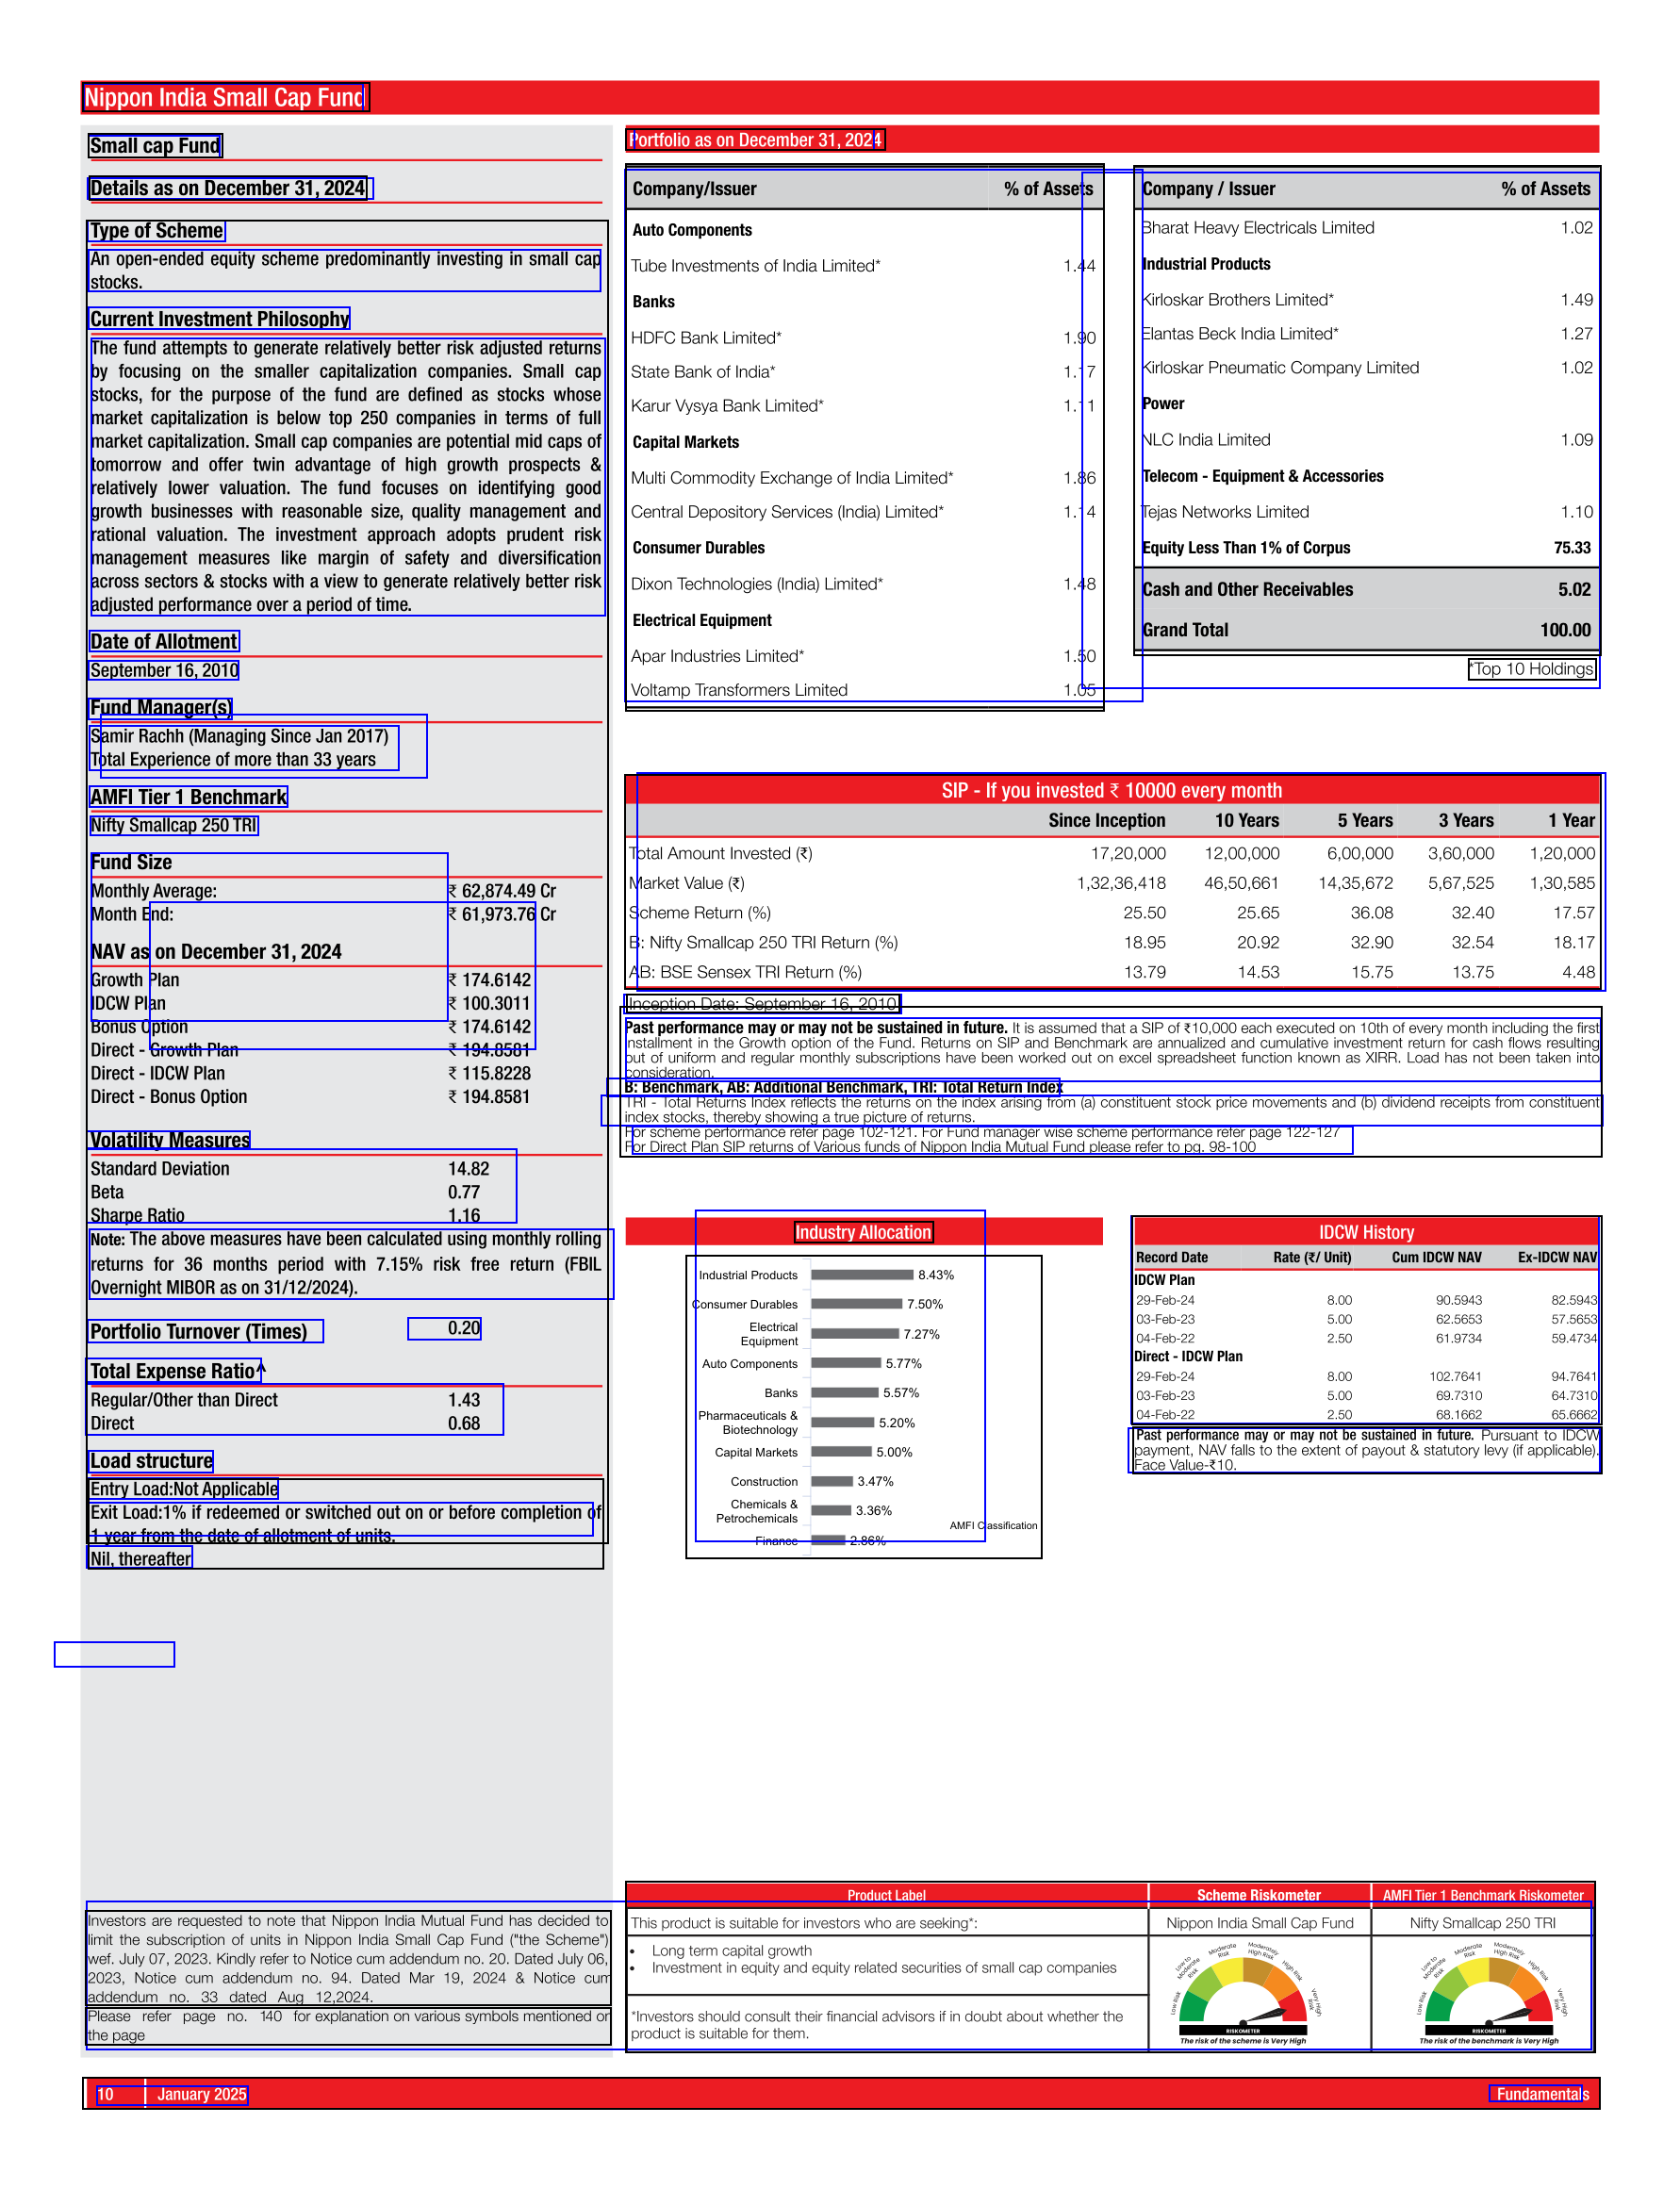

In [60]:
draw_bounding_boxes(temp_image,lay,resize=False,color="black")

In [ ]:
combine_surya_and_layout_reader_bboxes(bboxes,list(lay))

[0, 0, 0, 0, 0, 0, 0, 12, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0]

In [103]:
i=-1
croped=a.get_bounded_image(image,ordered_big_boxes)


In [99]:
croped[0]

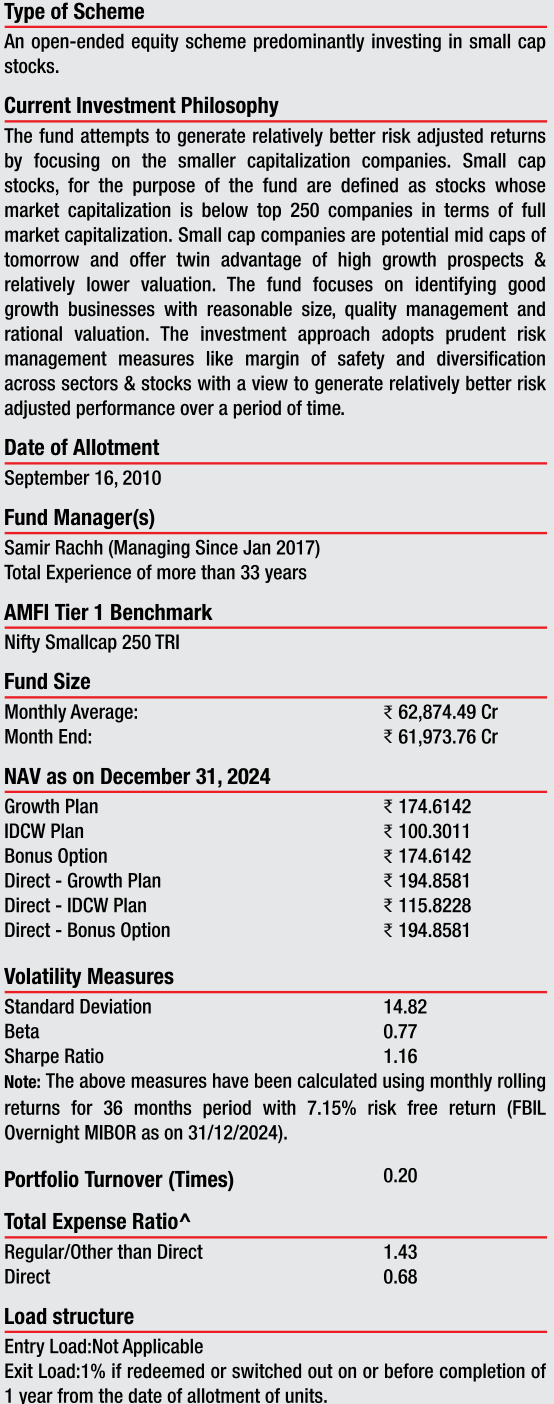

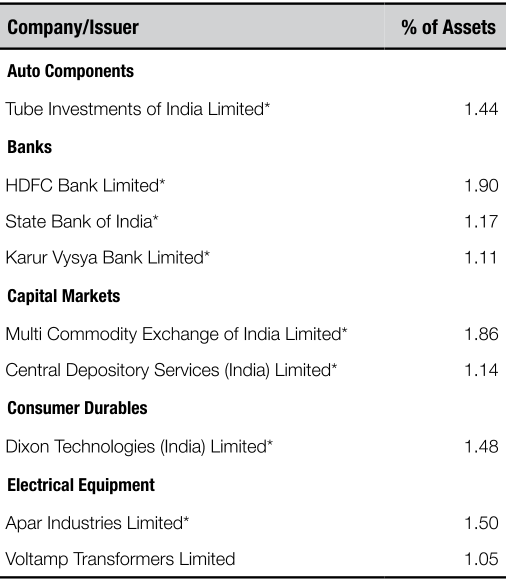

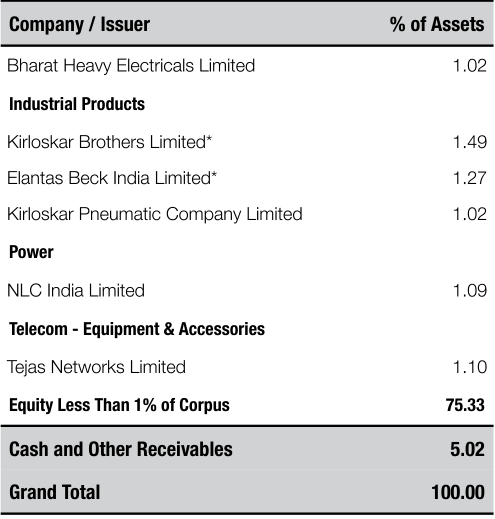

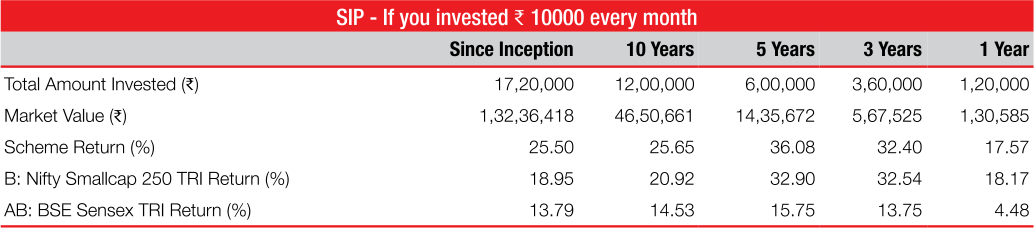

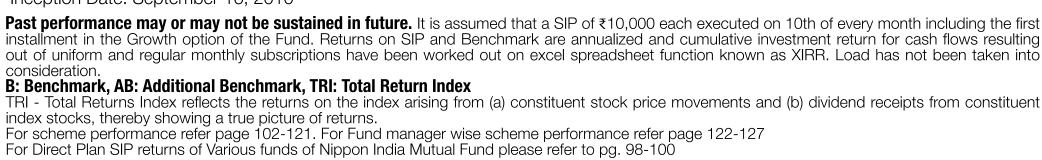

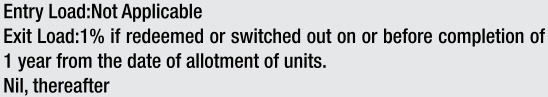

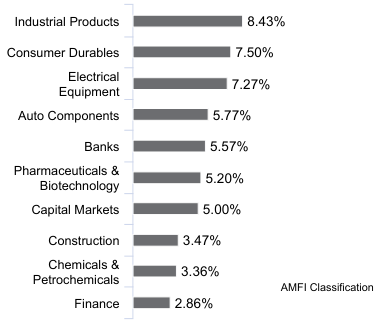

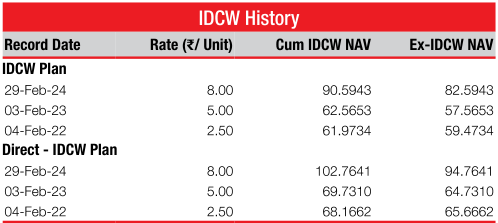

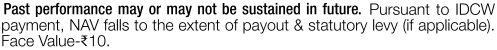

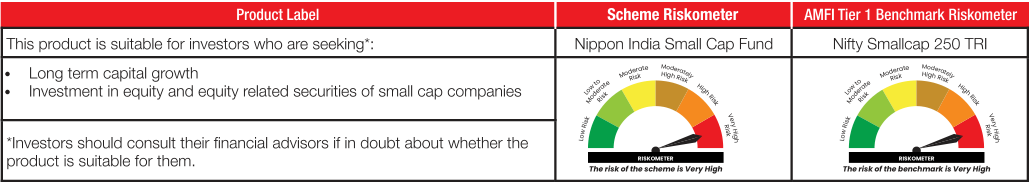

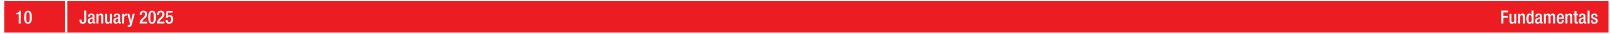

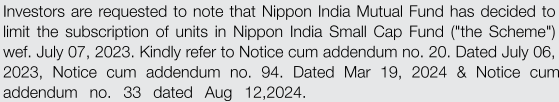

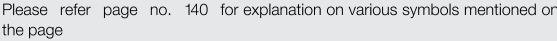

In [104]:
from IPython.display import display
from PIL import Image

# Assuming `croped` is a list of cropped images
for img in croped:  # Ensure 'cropped' contains the images
    display(img)